In [1]:
from transformers import GPT2LMHeadModel

In [2]:
model_hf = GPT2LMHeadModel.from_pretrained("gpt2") # 124M by default

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

In [3]:
sd_hf = model_hf.state_dict()

In [4]:
for k, v in sd_hf.items():
  print(k, v.shape)

transformer.wte.weight torch.Size([50257, 768])
transformer.wpe.weight torch.Size([1024, 768])
transformer.h.0.ln_1.weight torch.Size([768])
transformer.h.0.ln_1.bias torch.Size([768])
transformer.h.0.attn.c_attn.weight torch.Size([768, 2304])
transformer.h.0.attn.c_attn.bias torch.Size([2304])
transformer.h.0.attn.c_proj.weight torch.Size([768, 768])
transformer.h.0.attn.c_proj.bias torch.Size([768])
transformer.h.0.ln_2.weight torch.Size([768])
transformer.h.0.ln_2.bias torch.Size([768])
transformer.h.0.mlp.c_fc.weight torch.Size([768, 3072])
transformer.h.0.mlp.c_fc.bias torch.Size([3072])
transformer.h.0.mlp.c_proj.weight torch.Size([3072, 768])
transformer.h.0.mlp.c_proj.bias torch.Size([768])
transformer.h.1.ln_1.weight torch.Size([768])
transformer.h.1.ln_1.bias torch.Size([768])
transformer.h.1.attn.c_attn.weight torch.Size([768, 2304])
transformer.h.1.attn.c_attn.bias torch.Size([2304])
transformer.h.1.attn.c_proj.weight torch.Size([768, 768])
transformer.h.1.attn.c_proj.bias 

### Model Configuration Notes

- **Embedding dimension:** 768  
- **Vocabulary size:** 50,257  
- **Maximum sequence length (context window):** 1,024 tokens  

Each token is represented by a **768-dimensional embedding vector**.  
The model can process sequences of up to **1,024 tokens** at a time,  
and the tokenizer maps text into a vocabulary of **50,257 unique tokens**.

In [5]:
sd_hf["transformer.wpe.weight"].view(-1)[:20]

tensor([-0.0188, -0.1974,  0.0040,  0.0113,  0.0638, -0.1050,  0.0369, -0.1680,
        -0.0491, -0.0565, -0.0025,  0.0135, -0.0042,  0.0151,  0.0166, -0.1381,
        -0.0063, -0.0461,  0.0267, -0.2042])

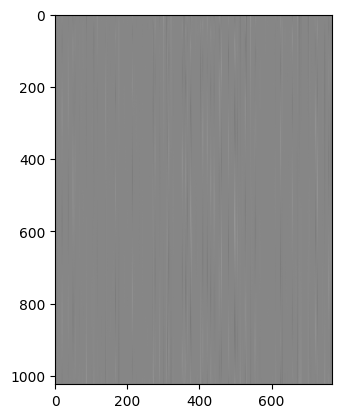

In [6]:
import matplotlib.pyplot as plt
%matplotlib inline
plt.imshow(sd_hf["transformer.wpe.weight"], cmap="gray")

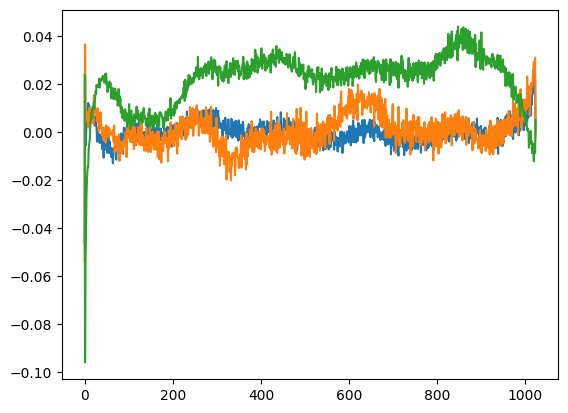

In [7]:
plt.plot(sd_hf["transformer.wpe.weight"][:, 150])
plt.plot(sd_hf["transformer.wpe.weight"][:, 200])
plt.plot(sd_hf["transformer.wpe.weight"][:, 250])

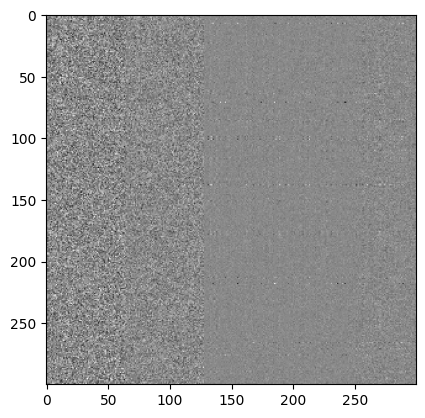

In [8]:
plt.imshow(sd_hf["transformer.h.1.attn.c_attn.weight"][:300, :300], cmap='gray')

In [9]:
from transformers import  pipeline, set_seed

generator = pipeline('text-generation', model='gpt2')
set_seed(42)
generator("Hello I am a language model", max_new_tokens=30, num_return_sequences=5)

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

Passing `generation_config` together with generation-related arguments=({'max_new_tokens', 'num_return_sequences'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Both `max_new_tokens` (=30) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


[{'generated_text': 'Hello I am a language model for you" —Miles Teller, The Times, March 11, 2005\n\n"An Introduction to Language Theory" is a book that has'},
 {'generated_text': "Hello I am a language model. I'm not a designer. I am no programmer. I am a guy. I've been working for 5 years. I'm a man."},
 {'generated_text': 'Hello I am a language model for the real world," the teacher said. "But I am not a language model for the real world. I am a language model for the real'},
 {'generated_text': "Hello I am a language modeler. I've been writing for some time now and I've seen a lot of very interesting things in the programming world as well. I recently finished"},
 {'generated_text': 'Hello I am a language modeler, and I hope to write some of the best programming languages on the net. So, I am happy to announce that my project will be made'}]

## **Implementing the GPT-2**


In [10]:
from dataclasses import dataclass
import torch
import torch.nn as nn
from torch.nn import functional as F
import math
import time


## **GPT-2 is a decoder-only model.**

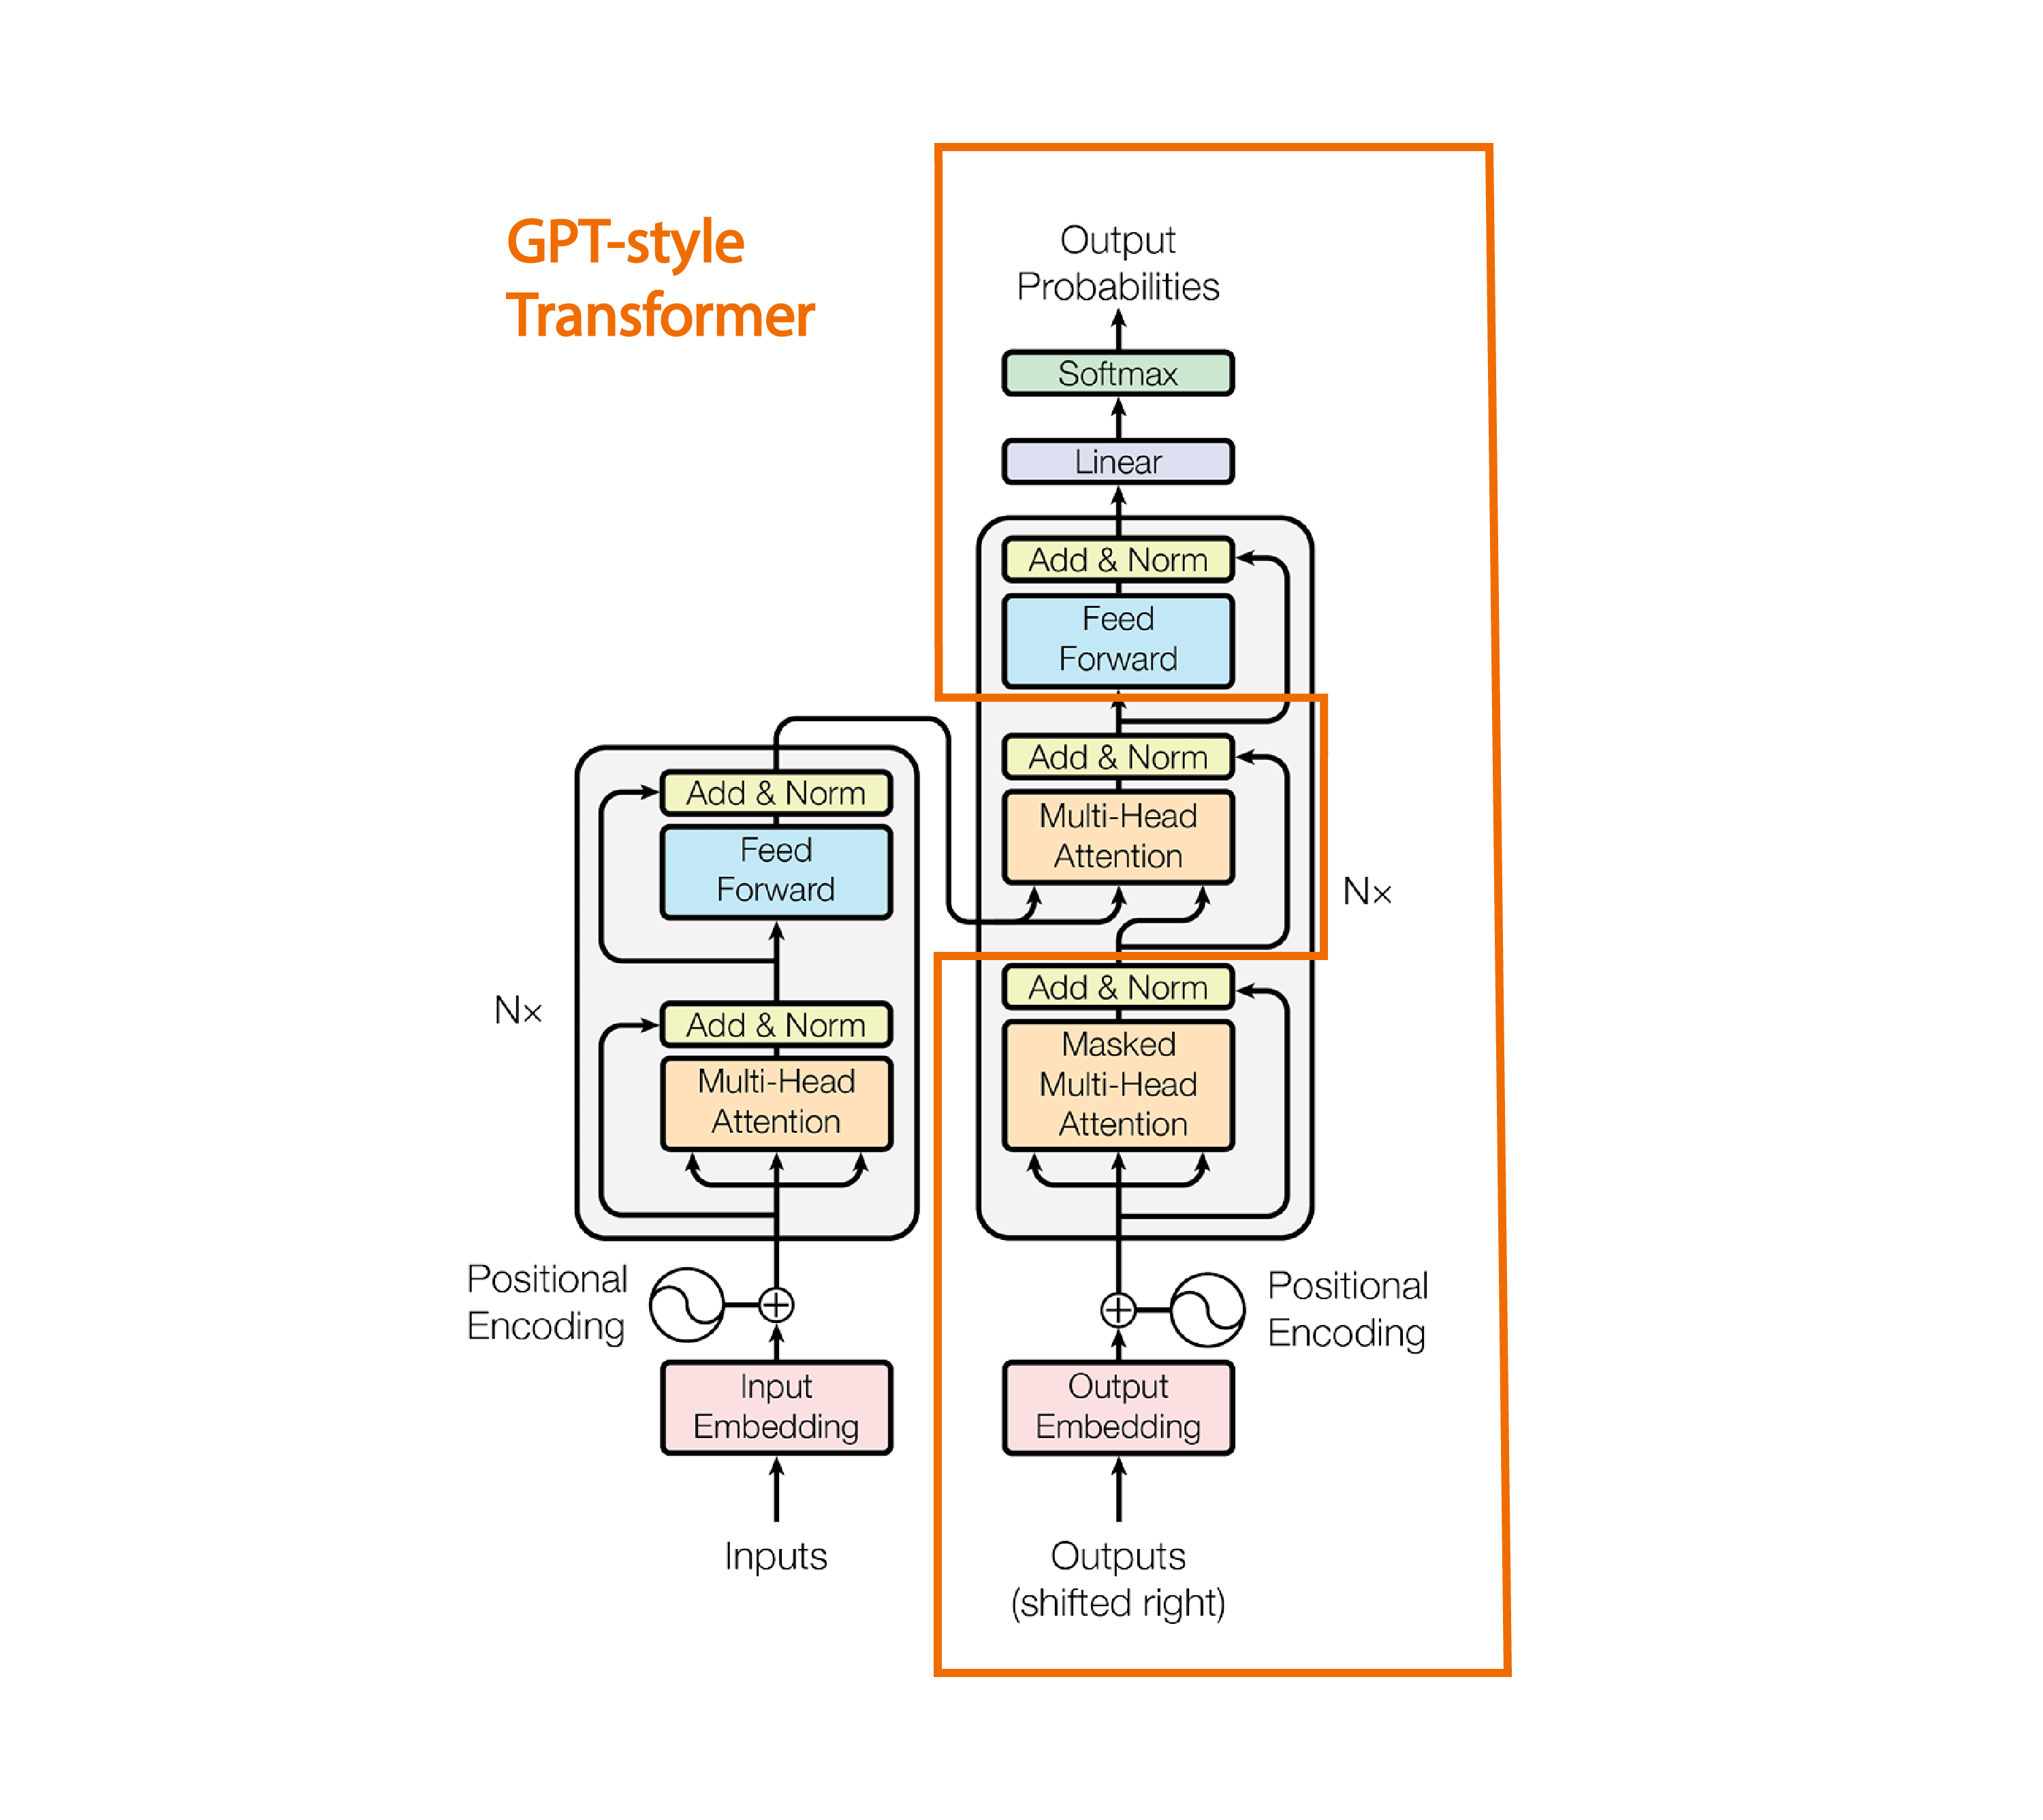

In GPT-2, all layer normalization layers are applied before the self-attention and MLP blocks rather than after them, and an additional layer normalization is added right before the final output (language modeling) layer.

In [11]:
class CausalSelfAttention(nn.Module):

    def __init__(self, config):
        super().__init__()
        assert config.n_embd % config.n_head == 0
        # key, query, value projections for all heads, but in a batch
        self.c_attn = nn.Linear(config.n_embd, 3 * config.n_embd)
        # output projection
        self.c_proj = nn.Linear(config.n_embd, config.n_embd)
        # regularization
        self.n_head = config.n_head
        self.n_embd = config.n_embd
        # not really a 'bias', more of a mask, but following the OpenAI/HF naming though
        self.register_buffer("bias", torch.tril(torch.ones(config.block_size, config.block_size))
                                     .view(1, 1, config.block_size, config.block_size))

    def forward(self, x):
        B, T, C = x.size() # batch size, sequence length, embedding dimensionality (n_embd)
        # calculate query, key, values for all heads in batch and move head forward to be the batch dim
        # nh is "number of heads", hs is "head size" and C "number of channels"= nh * hs
        # in GPT-2 (124M) n_head = 12, hs=64, so nh*hs=768 channels in the Transformer
        qkv = self.c_attn(x)
        q, k, v = qkv.split(self.n_embd, dim=2)
        k = k.view(B, T, self.n_head, C // self.n_head).transpose(1, 2) # (B, nh, T, hs)
        q = q.view(B, T, self.n_head, C // self.n_head).transpose(1, 2) # (B, nh, T, hs)
        v = v.view(B, T, self.n_head, C // self.n_head).transpose(1, 2) # (B, nh, T, hs)
        # attention materializes the large (T,T) matrix for all the queries and keys
        att = (q @ k.transpose(-2, -1)) * (1.0 / math.sqrt(k.size(-1)))
        att = att.masked_fill(self.bias[:,:,:T,:T] == 0, float('-inf'))
        att = F.softmax(att, dim=-1)
        y = att @ v # (B, nh, T, T) x (B, nh, T, hs) -> (B, nh, T, hs)
        y = y.transpose(1, 2).contiguous().view(B, T, C) # re-assemble all head outputs side by side
        # output projection
        y = self.c_proj(y)
        return y

class MLP(nn.Module):

    def __init__(self, config):
        super().__init__()
        self.c_fc    = nn.Linear(config.n_embd, 4 * config.n_embd)
        self.gelu = nn.GELU(approximate="tanh")  # GELU non-linearity; similar to ReLU but smoother
        self.c_proj  = nn.Linear(4 * config.n_embd, config.n_embd)

    def forward(self, x):
        x = self.c_fc(x)
        x = self.gelu(x)
        x = self.c_proj(x)
        return x



class Block(nn.Module):

    def __init__(self, config):
        super().__init__()
        self.ln_1 = nn.LayerNorm(config.n_embd)
        self.attn = CausalSelfAttention(config)
        self.ln_2 = nn.LayerNorm(config.n_embd)
        self.mlp = MLP(config)

    def forward(self, x):
        x = x + self.attn(self.ln_1(x))   # LayerNorm BEFORE self-attention
        x = x + self.mlp(self.ln_2(x))    # LayerNorm BEFORE MLP
        return x

@dataclass
class GPTConfig:
    block_size: int = 1024 # max sequence length
    vocab_size: int = 50257 # number of tokens: 50000 BPE merges + 256 byte tokens + 1 <|endoftext|> token
    n_layer: int = 12 # number of layers
    n_head: int = 12 # number of heads
    n_embd: int = 768 # embedding dimension

class GPT(nn.Module):

    def __init__(self, config):
        super().__init__()
        self.config = config

        self.transformer = nn.ModuleDict(dict(
            wte = nn.Embedding(config.vocab_size, config.n_embd),
            wpe = nn.Embedding(config.block_size, config.n_embd),
            h = nn.ModuleList([Block(config) for _ in range(config.n_layer)]),
            ln_f = nn.LayerNorm(config.n_embd),
        ))
        self.lm_head = nn.Linear(config.n_embd, config.vocab_size, bias=False)

    def forward(self, idx):
        # idx is of shape (B, T)
        B, T = idx.size()
        assert T <= self.config.block_size, f"Cannot forward sequence of length {T}, block size is only {self.config.block_size}"
        # forward the token and position embeddings
        pos = torch.arange(0, T, dtype=torch.long, device=idx.device) # shape (T)
        tok_emb = self.transformer.wte(idx) # token embeddings of shape (B, T, n_embd)
        pos_emb = self.transformer.wpe(pos) # position embeddings of shape (T, n_embd)

        x = tok_emb + pos_emb
        # forward the blocks of the transformer
        for block in self.transformer.h:
          x = block(x)

        # forward the final layer norm and the classifier
        x = self.transformer.ln_f(x)
        logits = self.lm_head(x) # B, T, vocab_size
        return logits


# <------------------------------Loading the huggingface/GPT-2 parameters-------------------------------->

    @classmethod
    def from_pretrained(cls, model_type):
        """Loads pretrained GPT-2 model weights from huggingface"""
        assert model_type in {'gpt2', 'gpt2-medium', 'gpt2-large', 'gpt2-xl'}
        from transformers import GPT2LMHeadModel
        print("loading weights from pretrained gpt: %s" % model_type)

        # n_layer, n_head and n_embd are determined from model_type
        config_args = {
            'gpt2':         dict(n_layer=12, n_head=12, n_embd=768),  # 124M params
            'gpt2-medium':  dict(n_layer=24, n_head=16, n_embd=1024), # 350M params
            'gpt2-large':   dict(n_layer=36, n_head=20, n_embd=1280), # 774M params
            'gpt2-xl':      dict(n_layer=48, n_head=25, n_embd=1600), # 1558M params
        }[model_type]
        config_args['vocab_size'] = 50257 # always 50257 for GPT model checkpoints
        config_args['block_size'] = 1024 # always 1024 for GPT model checkpoints

        # create a from-scratch initialized minGPT model
        config = GPTConfig(**config_args)
        model = GPT(config)
        sd = model.state_dict()
        sd_keys = sd.keys()
        sd_keys = [k for k in sd_keys if not k.endswith('.attn.bias')] # discard this mask / buffer, not a param

        # init a huggingface/transformers model
        model_hf = GPT2LMHeadModel.from_pretrained(model_type)
        sd_hf = model_hf.state_dict()

        # copy while ensuring all of the parameters are aligned and match in names and shapes
        sd_keys_hf = sd_hf.keys()
        sd_keys_hf = [k for k in sd_keys_hf if not k.endswith('.attn.masked_bias')] # ignore these, just a buffer
        sd_keys_hf = [k for k in sd_keys_hf if not k.endswith('.attn.bias')] # same, just the mask (buffer)
        transposed = ['attn.c_attn.weight', 'attn.c_proj.weight', 'mlp.c_fc.weight', 'mlp.c_proj.weight']
        # basically the openai checkpoints use a "Conv1D" module, but we only want to use a vanilla Linear
        # this means that we have to transpose these weights when we import them
        assert len(sd_keys_hf) == len(sd_keys), f"mismatched keys: {len(sd_keys_hf)} != {len(sd_keys)}"

        for k in sd_keys_hf:
            if any(k.endswith(w) for w in transposed):
                # special treatment for the Conv1D weights we need to transpose
                assert sd_hf[k].shape[::-1] == sd[k].shape
                with torch.no_grad():
                    sd[k].copy_(sd_hf[k].t())
            else:
                # vanilla copy over the other parameters
                assert sd_hf[k].shape == sd[k].shape
                with torch.no_grad():
                    sd[k].copy_(sd_hf[k])

        return model


# ------------------------------------------------------------------------------------------------------------------------------------
num_return_sequences = 5
max_length = 30

model = GPT.from_pretrained('gpt2')
model.eval()
model.to('cuda')


# prefix tokens
import tiktoken
enc = tiktoken.get_encoding('gpt2')
tokens = enc.encode('Hello I am a language model,')
tokens = torch.tensor(tokens, dtype=torch.long)  # (8,)
tokens = tokens.unsqueeze(0).repeat(num_return_sequences, 1)  # (5, 8)
x = tokens.to('cuda')


# generate! right now x is (B, T) where B = 5, T = 8
# set seed to 42
torch.manual_seed(42)
torch.cuda.manual_seed(42)

while x.size(1) < max_length:
  # forward the model to get logits

  with torch.no_grad():
    logits = model(x) # (B, T, vocab_size)
    # take the logits at the last position
    logits = logits[:, -1, :] # (B, vocab_size)
    # get the probabilities
    probs = F.softmax(logits, dim=-1)
    # do top-k sampling of 50 (huggingface pipeline default)
    # top_k_probs becomes (5, 50), top_k_indices is (5, 50)
    top_k_probs, top_k_indices = torch.topk(probs, 50, dim=-1)

    # select a token from the top-k probabilities
    ix = torch.multinomial(top_k_probs, 1)  # (B, 1)

    # gather the corresponding indices
    xcol = torch.gather(top_k_indices, -1, ix)  # (B, 1)

    # append to the sequence
    x = torch.cat((x, xcol), dim=1)


# print the generated text
for i in range(num_return_sequences):
    tokens = x[i, :max_length].tolist()
    decoded = enc.decode(tokens)
    print('>', decoded)

loading weights from pretrained gpt: gpt2


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


> Hello I am a language model, I am writing a program using it! -Lisp

Hello it works! You can also write an application
> Hello I am a language model, and we learn from our mistakes, not from ours in class, or not from the way we think the world works
> Hello I am a language model, not a dialect."

Piggy back.

Piggy back.

Piggy
> Hello I am a language model, and we are going to create an actual model - a language model. So I put all our data out there.
> Hello I am a language model, a language model to be specific to some aspect of you. For example, I think it is very useful in language


We previously initialized the model with GPT-2 pretrained weights, but now we want to initialize it from scratch with random weights and train it so that it generates sequences of equal or better quality.

In [12]:
class CausalSelfAttention(nn.Module):

    def __init__(self, config):
        super().__init__()
        assert config.n_embd % config.n_head == 0
        # key, query, value projections for all heads, but in a batch
        self.c_attn = nn.Linear(config.n_embd, 3 * config.n_embd)
        # output projection
        self.c_proj = nn.Linear(config.n_embd, config.n_embd)
        # regularization
        self.n_head = config.n_head
        self.n_embd = config.n_embd
        # not really a 'bias', more of a mask, but following the OpenAI/HF naming though
        self.register_buffer("bias", torch.tril(torch.ones(config.block_size, config.block_size))
                                     .view(1, 1, config.block_size, config.block_size))

    def forward(self, x):
        B, T, C = x.size() # batch size, sequence length, embedding dimensionality (n_embd)
        # calculate query, key, values for all heads in batch and move head forward to be the batch dim
        # nh is "number of heads", hs is "head size" and C "number of channels"= nh * hs
        # in GPT-2 (124M) n_head = 12, hs=64, so nh*hs=768 channels in the Transformer
        qkv = self.c_attn(x)
        q, k, v = qkv.split(self.n_embd, dim=2)
        k = k.view(B, T, self.n_head, C // self.n_head).transpose(1, 2) # (B, nh, T, hs)
        q = q.view(B, T, self.n_head, C // self.n_head).transpose(1, 2) # (B, nh, T, hs)
        v = v.view(B, T, self.n_head, C // self.n_head).transpose(1, 2) # (B, nh, T, hs)
        # attention materializes the large (T,T) matrix for all the queries and keys
        att = (q @ k.transpose(-2, -1)) * (1.0 / math.sqrt(k.size(-1)))
        att = att.masked_fill(self.bias[:,:,:T,:T] == 0, float('-inf'))
        att = F.softmax(att, dim=-1)
        y = att @ v # (B, nh, T, T) x (B, nh, T, hs) -> (B, nh, T, hs)
        y = y.transpose(1, 2).contiguous().view(B, T, C) # re-assemble all head outputs side by side
        # output projection
        y = self.c_proj(y)
        return y

class MLP(nn.Module):

    def __init__(self, config):
        super().__init__()
        self.c_fc    = nn.Linear(config.n_embd, 4 * config.n_embd)
        self.gelu = nn.GELU(approximate="tanh")  # GELU non-linearity; similar to ReLU but smoother
        self.c_proj  = nn.Linear(4 * config.n_embd, config.n_embd)

    def forward(self, x):
        x = self.c_fc(x)
        x = self.gelu(x)
        x = self.c_proj(x)
        return x



class Block(nn.Module):

    def __init__(self, config):
        super().__init__()
        self.ln_1 = nn.LayerNorm(config.n_embd)
        self.attn = CausalSelfAttention(config)
        self.ln_2 = nn.LayerNorm(config.n_embd)
        self.mlp = MLP(config)

    def forward(self, x):
        x = x + self.attn(self.ln_1(x))   # LayerNorm BEFORE self-attention
        x = x + self.mlp(self.ln_2(x))    # LayerNorm BEFORE MLP
        return x

@dataclass
class GPTConfig:
    block_size: int = 1024 # max sequence length
    vocab_size: int = 50257 # number of tokens: 50000 BPE merges + 256 byte tokens + 1 <|endoftext|> token
    n_layer: int = 12 # number of layers
    n_head: int = 12 # number of heads
    n_embd: int = 768 # embedding dimension

class GPT(nn.Module):

    def __init__(self, config):
        super().__init__()
        self.config = config

        self.transformer = nn.ModuleDict(dict(
            wte = nn.Embedding(config.vocab_size, config.n_embd),
            wpe = nn.Embedding(config.block_size, config.n_embd),
            h = nn.ModuleList([Block(config) for _ in range(config.n_layer)]),
            ln_f = nn.LayerNorm(config.n_embd),
        ))
        self.lm_head = nn.Linear(config.n_embd, config.vocab_size, bias=False)

    def forward(self, idx):
        # idx is of shape (B, T)
        B, T = idx.size()
        assert T <= self.config.block_size, f"Cannot forward sequence of length {T}, block size is only {self.config.block_size}"
        # forward the token and position embeddings
        pos = torch.arange(0, T, dtype=torch.long, device=idx.device) # shape (T)
        tok_emb = self.transformer.wte(idx) # token embeddings of shape (B, T, n_embd)
        pos_emb = self.transformer.wpe(pos) # position embeddings of shape (T, n_embd)

        x = tok_emb + pos_emb
        # forward the blocks of the transformer
        for block in self.transformer.h:
          x = block(x)

        # forward the final layer norm and the classifier
        x = self.transformer.ln_f(x)
        logits = self.lm_head(x) # B, T, vocab_size
        return logits


# <------------------------------Loading the huggingface/GPT-2 parameters-------------------------------->

    @classmethod
    def from_pretrained(cls, model_type):
        """Loads pretrained GPT-2 model weights from huggingface"""
        assert model_type in {'gpt2', 'gpt2-medium', 'gpt2-large', 'gpt2-xl'}
        from transformers import GPT2LMHeadModel
        print("loading weights from pretrained gpt: %s" % model_type)

        # n_layer, n_head and n_embd are determined from model_type
        config_args = {
            'gpt2':         dict(n_layer=12, n_head=12, n_embd=768),  # 124M params
            'gpt2-medium':  dict(n_layer=24, n_head=16, n_embd=1024), # 350M params
            'gpt2-large':   dict(n_layer=36, n_head=20, n_embd=1280), # 774M params
            'gpt2-xl':      dict(n_layer=48, n_head=25, n_embd=1600), # 1558M params
        }[model_type]
        config_args['vocab_size'] = 50257 # always 50257 for GPT model checkpoints
        config_args['block_size'] = 1024 # always 1024 for GPT model checkpoints

        # create a from-scratch initialized minGPT model
        config = GPTConfig(**config_args)
        model = GPT(config)
        sd = model.state_dict()
        sd_keys = sd.keys()
        sd_keys = [k for k in sd_keys if not k.endswith('.attn.bias')] # discard this mask / buffer, not a param

        # init a huggingface/transformers model
        model_hf = GPT2LMHeadModel.from_pretrained(model_type)
        sd_hf = model_hf.state_dict()

        # copy while ensuring all of the parameters are aligned and match in names and shapes
        sd_keys_hf = sd_hf.keys()
        sd_keys_hf = [k for k in sd_keys_hf if not k.endswith('.attn.masked_bias')] # ignore these, just a buffer
        sd_keys_hf = [k for k in sd_keys_hf if not k.endswith('.attn.bias')] # same, just the mask (buffer)
        transposed = ['attn.c_attn.weight', 'attn.c_proj.weight', 'mlp.c_fc.weight', 'mlp.c_proj.weight']
        # basically the openai checkpoints use a "Conv1D" module, but we only want to use a vanilla Linear
        # this means that we have to transpose these weights when we import them
        assert len(sd_keys_hf) == len(sd_keys), f"mismatched keys: {len(sd_keys_hf)} != {len(sd_keys)}"

        for k in sd_keys_hf:
            if any(k.endswith(w) for w in transposed):
                # special treatment for the Conv1D weights we need to transpose
                assert sd_hf[k].shape[::-1] == sd[k].shape
                with torch.no_grad():
                    sd[k].copy_(sd_hf[k].t())
            else:
                # vanilla copy over the other parameters
                assert sd_hf[k].shape == sd[k].shape
                with torch.no_grad():
                    sd[k].copy_(sd_hf[k])

        return model


# ------------------------------------------------------------------------------------------------------------------------------------
# attempt to autodetect the device
device = 'cpu'
if torch.cuda.is_available():
    device = 'cuda'
print(f"using device: {device}")
num_return_sequences = 5
max_length = 30

model = GPT(GPTConfig())
model.eval()
model.to('cuda')


# prefix tokens
import tiktoken
enc = tiktoken.get_encoding('gpt2')
tokens = enc.encode('Hello I am a language model,')
tokens = torch.tensor(tokens, dtype=torch.long)  # (8,)
tokens = tokens.unsqueeze(0).repeat(num_return_sequences, 1)  # (5, 8)
x = tokens.to('cuda')


# generate! right now x is (B, T) where B = 5, T = 8
# set seed to 42
torch.manual_seed(42)
torch.cuda.manual_seed(42)

while x.size(1) < max_length:
  # forward the model to get logits

  with torch.no_grad():
    logits = model(x) # (B, T, vocab_size)
    # take the logits at the last position
    logits = logits[:, -1, :] # (B, vocab_size)
    # get the probabilities
    probs = F.softmax(logits, dim=-1)
    # do top-k sampling of 50 (huggingface pipeline default)
    # top_k_probs becomes (5, 50), top_k_indices is (5, 50)
    top_k_probs, top_k_indices = torch.topk(probs, 50, dim=-1)

    # select a token from the top-k probabilities
    ix = torch.multinomial(top_k_probs, 1)  # (B, 1)

    # gather the corresponding indices
    xcol = torch.gather(top_k_indices, -1, ix)  # (B, 1)

    # append to the sequence
    x = torch.cat((x, xcol), dim=1)


# print the generated text
for i in range(num_return_sequences):
    tokens = x[i, :max_length].tolist()
    decoded = enc.decode(tokens)
    print('>', decoded)

using device: cuda
> Hello I am a language model, shareholder flown yoga�237 Bin cooler assassinatedHuntilles Ant509 Panama enc187 festive your Zoo confirming ANNMiamiletcher Thomas
> Hello I am a language model, Cre Copyrighturbanposal compressionantyestroicating depressive Piece cultivated joint Ibn bribeesthes Tags slumped mosquito pervasiveHon Dol Keen Mongol
> Hello I am a language model, Scripture fixtureasmSpecial grid inhab Brewers dollar instituteWhere Pruoked solve neglect Phoenix Observer couponcenterа creeps Blessed accompanied De
> Hello I am a language model, EVs shimmer insecurityLenin antibodiesuniversalcolm Rhod consulted Shaun blur Era finish fieldingThatura 390!!ulzBuffer pointing Trailer crammed
> Hello I am a language model, persistencereply procession announces sabot�itement ISIS lipid mating Faw perpetrators paternal Hon accommodatingfont Graphics supplementationMex biblical Pikachusoonemer


In [13]:
!wget https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt

--2026-03-04 15:30:26--  https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1115394 (1.1M) [text/plain]
Saving to: ‘input.txt’

input.txt           100%[===================>]   1.06M  --.-KB/s    in 0.005s  

2026-03-04 15:30:26 (209 MB/s) - ‘input.txt’ saved [1115394/1115394]



In [14]:
class CausalSelfAttention(nn.Module):

    def __init__(self, config):
        super().__init__()
        assert config.n_embd % config.n_head == 0
        # key, query, value projections for all heads, but in a batch
        self.c_attn = nn.Linear(config.n_embd, 3 * config.n_embd)
        # output projection
        self.c_proj = nn.Linear(config.n_embd, config.n_embd)
        self.c_proj.NANOGPT_SCALE_INIT = 1
        # regularization
        self.n_head = config.n_head
        self.n_embd = config.n_embd
        # not really a 'bias', more of a mask, but following the OpenAI/HF naming though
        self.register_buffer("bias", torch.tril(torch.ones(config.block_size, config.block_size))
                                     .view(1, 1, config.block_size, config.block_size))

    def forward(self, x):
        B, T, C = x.size() # batch size, sequence length, embedding dimensionality (n_embd)
        # calculate query, key, values for all heads in batch and move head forward to be the batch dim
        # nh is "number of heads", hs is "head size" and C "number of channels"= nh * hs
        # in GPT-2 (124M) n_head = 12, hs=64, so nh*hs=768 channels in the Transformer
        qkv = self.c_attn(x)
        q, k, v = qkv.split(self.n_embd, dim=2)
        k = k.view(B, T, self.n_head, C // self.n_head).transpose(1, 2) # (B, nh, T, hs)
        q = q.view(B, T, self.n_head, C // self.n_head).transpose(1, 2) # (B, nh, T, hs)
        v = v.view(B, T, self.n_head, C // self.n_head).transpose(1, 2) # (B, nh, T, hs)
        # attention materializes the large (T,T) matrix for all the queries and keys
        att = (q @ k.transpose(-2, -1)) * (1.0 / math.sqrt(k.size(-1)))
        att = att.masked_fill(self.bias[:,:,:T,:T] == 0, float('-inf'))
        att = F.softmax(att, dim=-1)
        y = att @ v # (B, nh, T, T) x (B, nh, T, hs) -> (B, nh, T, hs)
        y = y.transpose(1, 2).contiguous().view(B, T, C) # re-assemble all head outputs side by side
        # output projection
        y = self.c_proj(y)
        return y


class MLP(nn.Module):

    def __init__(self, config):
        super().__init__()
        self.c_fc    = nn.Linear(config.n_embd, 4 * config.n_embd)
        self.gelu = nn.GELU(approximate="tanh")  # GELU non-linearity; similar to ReLU but smoother
        self.c_proj  = nn.Linear(4 * config.n_embd, config.n_embd)
        self.c_proj.NANOGPT_SCALE_INIT = 1

    def forward(self, x):
        x = self.c_fc(x)
        x = self.gelu(x)
        x = self.c_proj(x)
        return x



class Block(nn.Module):

    def __init__(self, config):
        super().__init__()
        self.ln_1 = nn.LayerNorm(config.n_embd)
        self.attn = CausalSelfAttention(config)
        self.ln_2 = nn.LayerNorm(config.n_embd)
        self.mlp = MLP(config)

    def forward(self, x):
        x = x + self.attn(self.ln_1(x))   # LayerNorm BEFORE self-attention
        x = x + self.mlp(self.ln_2(x))    # LayerNorm BEFORE MLP
        return x

@dataclass
class GPTConfig:
    block_size: int = 1024 # max sequence length
    vocab_size: int = 50257 # number of tokens: 50000 BPE merges + 256 byte tokens + 1 <|endoftext|> token
    n_layer: int = 12 # number of layers
    n_head: int = 12 # number of heads
    n_embd: int = 768 # embedding dimension

class GPT(nn.Module):

    def __init__(self, config):
        super().__init__()
        self.config = config

        self.transformer = nn.ModuleDict(dict(
            wte = nn.Embedding(config.vocab_size, config.n_embd),
            wpe = nn.Embedding(config.block_size, config.n_embd),
            h = nn.ModuleList([Block(config) for _ in range(config.n_layer)]),
            ln_f = nn.LayerNorm(config.n_embd),
        ))
        self.lm_head = nn.Linear(config.n_embd, config.vocab_size, bias=False)

        # weight sharing scheme
        self.transformer.wte.weight = self.lm_head.weight

        # init params
        self.apply(self._init_weights)

    def _init_weights(self, module):

        if isinstance(module, nn.Linear):
            std = 0.02
            if hasattr(module, 'NANOGPT_SCALE_INIT'):
                std *= (2 * self.config.n_layer) ** -0.5
            torch.nn.init.normal_(module.weight, mean=0.0, std=std)
            if module.bias is not None:
                torch.nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Embedding):
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)
    def forward(self, idx, targets=None):
        # idx is of shape (B, T)
        B, T = idx.size()
        assert T <= self.config.block_size, f"Cannot forward sequence of length {T}, block size is only {self.config.block_size}"
        # forward the token and position embeddings
        pos = torch.arange(0, T, dtype=torch.long, device=idx.device) # shape (T)
        tok_emb = self.transformer.wte(idx) # token embeddings of shape (B, T, n_embd)
        pos_emb = self.transformer.wpe(pos) # position embeddings of shape (T, n_embd)

        x = tok_emb + pos_emb
        # forward the blocks of the transformer
        for block in self.transformer.h:
          x = block(x)

        # forward the final layer norm and the classifier
        x = self.transformer.ln_f(x)
        loss = None
        logits = self.lm_head(x) # B, T, vocab_size

        if targets is not None:
            loss = F.cross_entropy(logits.view(-1, logits.size(-1)), targets.view(-1))
        return logits, loss


# <------------------------------Loading the huggingface/GPT-2 parameters-------------------------------->

    @classmethod
    def from_pretrained(cls, model_type):
        """Loads pretrained GPT-2 model weights from huggingface"""
        assert model_type in {'gpt2', 'gpt2-medium', 'gpt2-large', 'gpt2-xl'}
        from transformers import GPT2LMHeadModel
        print("loading weights from pretrained gpt: %s" % model_type)

        # n_layer, n_head and n_embd are determined from model_type
        config_args = {
            'gpt2':         dict(n_layer=12, n_head=12, n_embd=768),  # 124M params
            'gpt2-medium':  dict(n_layer=24, n_head=16, n_embd=1024), # 350M params
            'gpt2-large':   dict(n_layer=36, n_head=20, n_embd=1280), # 774M params
            'gpt2-xl':      dict(n_layer=48, n_head=25, n_embd=1600), # 1558M params
        }[model_type]
        config_args['vocab_size'] = 50257 # always 50257 for GPT model checkpoints
        config_args['block_size'] = 1024 # always 1024 for GPT model checkpoints

        # create a from-scratch initialized minGPT model
        config = GPTConfig(**config_args)
        model = GPT(config)
        sd = model.state_dict()
        sd_keys = sd.keys()
        sd_keys = [k for k in sd_keys if not k.endswith('.attn.bias')] # discard this mask / buffer, not a param

        # init a huggingface/transformers model
        model_hf = GPT2LMHeadModel.from_pretrained(model_type)
        sd_hf = model_hf.state_dict()

        # copy while ensuring all of the parameters are aligned and match in names and shapes
        sd_keys_hf = sd_hf.keys()
        sd_keys_hf = [k for k in sd_keys_hf if not k.endswith('.attn.masked_bias')] # ignore these, just a buffer
        sd_keys_hf = [k for k in sd_keys_hf if not k.endswith('.attn.bias')] # same, just the mask (buffer)
        transposed = ['attn.c_attn.weight', 'attn.c_proj.weight', 'mlp.c_fc.weight', 'mlp.c_proj.weight']
        # basically the openai checkpoints use a "Conv1D" module, but we only want to use a vanilla Linear
        # this means that we have to transpose these weights when we import them
        assert len(sd_keys_hf) == len(sd_keys), f"mismatched keys: {len(sd_keys_hf)} != {len(sd_keys)}"

        for k in sd_keys_hf:
            if any(k.endswith(w) for w in transposed):
                # special treatment for the Conv1D weights we need to transpose
                assert sd_hf[k].shape[::-1] == sd[k].shape
                with torch.no_grad():
                    sd[k].copy_(sd_hf[k].t())
            else:
                # vanilla copy over the other parameters
                assert sd_hf[k].shape == sd[k].shape
                with torch.no_grad():
                    sd[k].copy_(sd_hf[k])

        return model


# ------------------------------------------------------------------------------------------------------------------------------------
import tiktoken

class DataLoaderLite:

  def __init__(self, B, T):
      self.B = B
      self.T = T

      # at init load tokens from disk and stores them in memory
      with open('input.txt', 'r') as f:
          text = f.read()
      enc = tiktoken.get_encoding('gpt2')
      tokens = enc.encode(text)
      self.tokens = torch.tensor(tokens)
      print(f"loaded {len(self.tokens)} tokens")
      print(f"1 epoch = {len(self.tokens) // (B * T)} batches")

      # state
      self.current_position = 0

  def next_batch(self):
      B, T = self.B, self.T
      buf = self.tokens[self.current_position : self.current_position+B*T+1]
      x = (buf[:-1]).view(B, T) # inputs
      y = (buf[1:]).view(B, T) # targets
      # advance the position in the tensor
      self.current_position += B*T
      # if loading the next batch would be out of bounds, reset
      if self.current_position + (B * T + 1) > len(self.tokens):
          self.current_position = 0
      return x, y

# ------------------------------------------------------------------------------------------------------------------------------------


# attempt to autodetect the device
device = 'cpu'
if torch.cuda.is_available():
    device = 'cuda'
print(f"using device: {device}")

torch.manual_seed(1337)
if torch.cuda.is_available():
    torch.cuda.manual_seed(1337)

train_loader = DataLoaderLite(B=2, T=1024)

# torch.set_float32_matmul_precision('high')
# Not effective on NVIDIA T4 GPUs.
# The T4 is based on the Turing architecture (compute capability 7.5)
# and does NOT support TensorFloat-32 (TF32).
# On T4, float32 matmul will use standard FP32 tensor cores

model = GPT(GPTConfig())
model.to(device)
model = torch.compile(model)

import time
# optimize!
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4)
for i in range(50):
    t0 = time.time()
    x, y = train_loader.next_batch()
    x, y = x.to(device), y.to(device)
    optimizer.zero_grad()

    # with torch.autocast(device_type=device, dtype=torch.bfloat16):
    #    logits, loss = model(x, y)
    # Not recommended on NVIDIA T4.
    # T4 does NOT support native bfloat16 tensor core acceleration.
    # Instead on T4, use float16 (FP16) + GradScaler for best performance.

    logits, loss = model(x, y)
    loss.backward()
    optimizer.step()
    torch.cuda.synchronize()
    t1 = time.time()
    dt = (t1 - t0)*1000  # time difference in miliseconds
    tokens_per_sec = (train_loader.B * train_loader.T) / (t1 - t0)
    print(f"step {i}, loss: {loss.item()}, dt: {dt:.2f}ms, tok/sec: {tokens_per_sec:.2f}")

using device: cuda
loaded 338025 tokens
1 epoch = 165 batches


W0304 15:30:50.351000 2417 torch/_inductor/utils.py:1679] [0/0] Not enough SMs to use max_autotune_gemm mode


step 0, loss: 10.934581756591797, dt: 45665.86ms, tok/sec: 44.85
step 1, loss: 9.472171783447266, dt: 510.99ms, tok/sec: 4007.87
step 2, loss: 9.200075149536133, dt: 522.32ms, tok/sec: 3920.98
step 3, loss: 8.896629333496094, dt: 522.73ms, tok/sec: 3917.89
step 4, loss: 8.751441955566406, dt: 529.80ms, tok/sec: 3865.61
step 5, loss: 8.46125602722168, dt: 523.78ms, tok/sec: 3910.03
step 6, loss: 8.128143310546875, dt: 535.67ms, tok/sec: 3823.25
step 7, loss: 7.9809136390686035, dt: 525.80ms, tok/sec: 3895.02
step 8, loss: 7.694231986999512, dt: 522.25ms, tok/sec: 3921.52
step 9, loss: 7.507059574127197, dt: 517.28ms, tok/sec: 3959.18
step 10, loss: 7.310482978820801, dt: 522.11ms, tok/sec: 3922.53
step 11, loss: 6.877571105957031, dt: 518.67ms, tok/sec: 3948.59
step 12, loss: 6.932930946350098, dt: 514.69ms, tok/sec: 3979.08
step 13, loss: 6.809874534606934, dt: 517.99ms, tok/sec: 3953.71
step 14, loss: 6.771484851837158, dt: 515.37ms, tok/sec: 3973.82
step 15, loss: 6.586923599243164, 

## **Adding Flash Attention**

**Added Flash Attention and increased vocab_size (smth like adding fake tokens)**

In [15]:
class CausalSelfAttention(nn.Module):

    def __init__(self, config):
        super().__init__()
        assert config.n_embd % config.n_head == 0
        # key, query, value projections for all heads, but in a batch
        self.c_attn = nn.Linear(config.n_embd, 3 * config.n_embd)
        # output projection
        self.c_proj = nn.Linear(config.n_embd, config.n_embd)
        self.c_proj.NANOGPT_SCALE_INIT = 1
        # regularization
        self.n_head = config.n_head
        self.n_embd = config.n_embd
        # not really a 'bias', more of a mask, but following the OpenAI/HF naming though
        self.register_buffer("bias", torch.tril(torch.ones(config.block_size, config.block_size))
                                     .view(1, 1, config.block_size, config.block_size))

    def forward(self, x):
        B, T, C = x.size() # batch size, sequence length, embedding dimensionality (n_embd)
        # calculate query, key, values for all heads in batch and move head forward to be the batch dim
        # nh is "number of heads", hs is "head size" and C "number of channels"= nh * hs
        # in GPT-2 (124M) n_head = 12, hs=64, so nh*hs=768 channels in the Transformer
        qkv = self.c_attn(x)
        q, k, v = qkv.split(self.n_embd, dim=2)
        k = k.view(B, T, self.n_head, C // self.n_head).transpose(1, 2) # (B, nh, T, hs)
        q = q.view(B, T, self.n_head, C // self.n_head).transpose(1, 2) # (B, nh, T, hs)
        v = v.view(B, T, self.n_head, C // self.n_head).transpose(1, 2) # (B, nh, T, hs)
        # attention materializes the large (T,T) matrix for all the queries and keys
        # att = (q @ k.transpose(-2, -1)) * (1.0 / math.sqrt(k.size(-1)))
        # att = att.masked_fill(self.bias[:,:,:T,:T] == 0, float('-inf'))
        # att = F.softmax(att, dim=-1)
        # y = att @ v # (B, nh, T, T) x (B, nh, T, hs) -> (B, nh, T, hs)

        y = F.scaled_dot_product_attention(q, k, v, is_causal=True)

        y = y.transpose(1, 2).contiguous().view(B, T, C) # re-assemble all head outputs side by side
        # output projection
        y = self.c_proj(y)
        return y


class MLP(nn.Module):

    def __init__(self, config):
        super().__init__()
        self.c_fc    = nn.Linear(config.n_embd, 4 * config.n_embd)
        self.gelu = nn.GELU(approximate="tanh")  # GELU non-linearity; similar to ReLU but smoother
        self.c_proj  = nn.Linear(4 * config.n_embd, config.n_embd)
        self.c_proj.NANOGPT_SCALE_INIT = 1

    def forward(self, x):
        x = self.c_fc(x)
        x = self.gelu(x)
        x = self.c_proj(x)
        return x



class Block(nn.Module):

    def __init__(self, config):
        super().__init__()
        self.ln_1 = nn.LayerNorm(config.n_embd)
        self.attn = CausalSelfAttention(config)
        self.ln_2 = nn.LayerNorm(config.n_embd)
        self.mlp = MLP(config)

    def forward(self, x):
        x = x + self.attn(self.ln_1(x))   # LayerNorm BEFORE self-attention
        x = x + self.mlp(self.ln_2(x))    # LayerNorm BEFORE MLP
        return x

@dataclass
class GPTConfig:
    block_size: int = 1024 # max sequence length
    vocab_size: int = 50257 # number of tokens: 50000 BPE merges + 256 byte tokens + 1 <|endoftext|> token
    n_layer: int = 12 # number of layers
    n_head: int = 12 # number of heads
    n_embd: int = 768 # embedding dimension

class GPT(nn.Module):

    def __init__(self, config):
        super().__init__()
        self.config = config

        self.transformer = nn.ModuleDict(dict(
            wte = nn.Embedding(config.vocab_size, config.n_embd),
            wpe = nn.Embedding(config.block_size, config.n_embd),
            h = nn.ModuleList([Block(config) for _ in range(config.n_layer)]),
            ln_f = nn.LayerNorm(config.n_embd),
        ))
        self.lm_head = nn.Linear(config.n_embd, config.vocab_size, bias=False)

        # weight sharing scheme
        self.transformer.wte.weight = self.lm_head.weight

        # init params
        self.apply(self._init_weights)

    def _init_weights(self, module):

        if isinstance(module, nn.Linear):
            std = 0.02
            if hasattr(module, 'NANOGPT_SCALE_INIT'):
                std *= (2 * self.config.n_layer) ** -0.5
            torch.nn.init.normal_(module.weight, mean=0.0, std=std)
            if module.bias is not None:
                torch.nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Embedding):
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)
    def forward(self, idx, targets=None):
        # idx is of shape (B, T)
        B, T = idx.size()
        assert T <= self.config.block_size, f"Cannot forward sequence of length {T}, block size is only {self.config.block_size}"
        # forward the token and position embeddings
        pos = torch.arange(0, T, dtype=torch.long, device=idx.device) # shape (T)
        tok_emb = self.transformer.wte(idx) # token embeddings of shape (B, T, n_embd)
        pos_emb = self.transformer.wpe(pos) # position embeddings of shape (T, n_embd)

        x = tok_emb + pos_emb
        # forward the blocks of the transformer
        for block in self.transformer.h:
          x = block(x)

        # forward the final layer norm and the classifier
        x = self.transformer.ln_f(x)
        loss = None
        logits = self.lm_head(x) # B, T, vocab_size

        if targets is not None:
            loss = F.cross_entropy(logits.view(-1, logits.size(-1)), targets.view(-1))
        return logits, loss


# <------------------------------Loading the huggingface/GPT-2 parameters-------------------------------->

    @classmethod
    def from_pretrained(cls, model_type):
        """Loads pretrained GPT-2 model weights from huggingface"""
        assert model_type in {'gpt2', 'gpt2-medium', 'gpt2-large', 'gpt2-xl'}
        from transformers import GPT2LMHeadModel
        print("loading weights from pretrained gpt: %s" % model_type)

        # n_layer, n_head and n_embd are determined from model_type
        config_args = {
            'gpt2':         dict(n_layer=12, n_head=12, n_embd=768),  # 124M params
            'gpt2-medium':  dict(n_layer=24, n_head=16, n_embd=1024), # 350M params
            'gpt2-large':   dict(n_layer=36, n_head=20, n_embd=1280), # 774M params
            'gpt2-xl':      dict(n_layer=48, n_head=25, n_embd=1600), # 1558M params
        }[model_type]
        config_args['vocab_size'] = 50257 # always 50257 for GPT model checkpoints
        config_args['block_size'] = 1024 # always 1024 for GPT model checkpoints

        # create a from-scratch initialized minGPT model
        config = GPTConfig(**config_args)
        model = GPT(config)
        sd = model.state_dict()
        sd_keys = sd.keys()
        sd_keys = [k for k in sd_keys if not k.endswith('.attn.bias')] # discard this mask / buffer, not a param

        # init a huggingface/transformers model
        model_hf = GPT2LMHeadModel.from_pretrained(model_type)
        sd_hf = model_hf.state_dict()

        # copy while ensuring all of the parameters are aligned and match in names and shapes
        sd_keys_hf = sd_hf.keys()
        sd_keys_hf = [k for k in sd_keys_hf if not k.endswith('.attn.masked_bias')] # ignore these, just a buffer
        sd_keys_hf = [k for k in sd_keys_hf if not k.endswith('.attn.bias')] # same, just the mask (buffer)
        transposed = ['attn.c_attn.weight', 'attn.c_proj.weight', 'mlp.c_fc.weight', 'mlp.c_proj.weight']
        # basically the openai checkpoints use a "Conv1D" module, but we only want to use a vanilla Linear
        # this means that we have to transpose these weights when we import them
        assert len(sd_keys_hf) == len(sd_keys), f"mismatched keys: {len(sd_keys_hf)} != {len(sd_keys)}"

        for k in sd_keys_hf:
            if any(k.endswith(w) for w in transposed):
                # special treatment for the Conv1D weights we need to transpose
                assert sd_hf[k].shape[::-1] == sd[k].shape
                with torch.no_grad():
                    sd[k].copy_(sd_hf[k].t())
            else:
                # vanilla copy over the other parameters
                assert sd_hf[k].shape == sd[k].shape
                with torch.no_grad():
                    sd[k].copy_(sd_hf[k])

        return model


# ------------------------------------------------------------------------------------------------------------------------------------
import tiktoken

class DataLoaderLite:

  def __init__(self, B, T):
      self.B = B
      self.T = T

      # at init load tokens from disk and stores them in memory
      with open('input.txt', 'r') as f:
          text = f.read()
      enc = tiktoken.get_encoding('gpt2')
      tokens = enc.encode(text)
      self.tokens = torch.tensor(tokens)
      print(f"loaded {len(self.tokens)} tokens")
      print(f"1 epoch = {len(self.tokens) // (B * T)} batches")

      # state
      self.current_position = 0

  def next_batch(self):
      B, T = self.B, self.T
      buf = self.tokens[self.current_position : self.current_position+B*T+1]
      x = (buf[:-1]).view(B, T) # inputs
      y = (buf[1:]).view(B, T) # targets
      # advance the position in the tensor
      self.current_position += B*T
      # if loading the next batch would be out of bounds, reset
      if self.current_position + (B * T + 1) > len(self.tokens):
          self.current_position = 0
      return x, y

# ------------------------------------------------------------------------------------------------------------------------------------


# attempt to autodetect the device
device = 'cpu'
if torch.cuda.is_available():
    device = 'cuda'
print(f"using device: {device}")

torch.manual_seed(1337)
if torch.cuda.is_available():
    torch.cuda.manual_seed(1337)

train_loader = DataLoaderLite(B=2, T=1024)

model = GPT(GPTConfig(vocab_size=50304))
model.to(device)
model = torch.compile(model)

import time
# optimize!
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4)
for i in range(50):
    t0 = time.time()
    x, y = train_loader.next_batch()
    x, y = x.to(device), y.to(device)
    optimizer.zero_grad()
    logits, loss = model(x, y)
    loss.backward()
    optimizer.step()
    torch.cuda.synchronize()
    t1 = time.time()
    dt = (t1 - t0)*1000  # time difference in miliseconds
    tokens_per_sec = (train_loader.B * train_loader.T) / (t1 - t0)
    print(f"step {i}, loss: {loss.item()}, dt: {dt:.2f}ms, tok/sec: {tokens_per_sec:.2f}")

using device: cuda
loaded 338025 tokens
1 epoch = 165 batches
step 0, loss: 10.919702529907227, dt: 23587.14ms, tok/sec: 86.83
step 1, loss: 9.487153053283691, dt: 505.94ms, tok/sec: 4047.90
step 2, loss: 9.177750587463379, dt: 504.26ms, tok/sec: 4061.42
step 3, loss: 8.852129936218262, dt: 504.33ms, tok/sec: 4060.85
step 4, loss: 8.746212005615234, dt: 504.84ms, tok/sec: 4056.76
step 5, loss: 8.472028732299805, dt: 505.19ms, tok/sec: 4053.96
step 6, loss: 8.160688400268555, dt: 505.31ms, tok/sec: 4052.94
step 7, loss: 7.981453895568848, dt: 503.32ms, tok/sec: 4068.99
step 8, loss: 7.70048713684082, dt: 524.29ms, tok/sec: 3906.21
step 9, loss: 7.484872817993164, dt: 507.35ms, tok/sec: 4036.69
step 10, loss: 7.316435813903809, dt: 501.73ms, tok/sec: 4081.85
step 11, loss: 6.8676323890686035, dt: 510.22ms, tok/sec: 4013.92
step 12, loss: 6.964810371398926, dt: 506.90ms, tok/sec: 4040.22
step 13, loss: 6.8049540519714355, dt: 506.32ms, tok/sec: 4044.88
step 14, loss: 6.771274566650391, dt

## **SECTION 3: hyperpamaters, AdamW, gradient clipping, cosine decay ...**

**Optimizer**: Used `AdamW` with `lr=3e-4`, `betas=(0.9, 0.95)`, and `eps=1e-8`, matching standard GPT training setups.

**Gradient Clipping**: Applied global gradient norm clipping at 1.0 using torch.`nn.utils.clip_grad_norm_` to prevent exploding gradients.
If the gradient norm starts climbing consistently during training, it usually indicates instability or a potential bug in the model, data, or loss computation.

Training Step:
Forward pass → compute logits and cross-entropy loss.
Backward pass → compute gradients.
Clip gradients → update weights with `optimizer.step()`.

**Learning rate scheduler**: Used a `cosine decay` schedule with a warmup
LR starts at 0, ramps up to the initial value, then decays along a cosine curve down to about 10% of the initial LR over the training horizon.

In [20]:
import inspect

In [21]:

class CausalSelfAttention(nn.Module):

    def __init__(self, config):
        super().__init__()
        assert config.n_embd % config.n_head == 0
        # key, query, value projections for all heads, but in a batch
        self.c_attn = nn.Linear(config.n_embd, 3 * config.n_embd)
        # output projection
        self.c_proj = nn.Linear(config.n_embd, config.n_embd)
        self.c_proj.NANOGPT_SCALE_INIT = 1
        # regularization
        self.n_head = config.n_head
        self.n_embd = config.n_embd
        # not really a 'bias', more of a mask, but following the OpenAI/HF naming though
        self.register_buffer("bias", torch.tril(torch.ones(config.block_size, config.block_size))
                                     .view(1, 1, config.block_size, config.block_size))

    def forward(self, x):
        B, T, C = x.size() # batch size, sequence length, embedding dimensionality (n_embd)
        # calculate query, key, values for all heads in batch and move head forward to be the batch dim
        # nh is "number of heads", hs is "head size" and C "number of channels"= nh * hs
        # in GPT-2 (124M) n_head = 12, hs=64, so nh*hs=768 channels in the Transformer
        qkv = self.c_attn(x)
        q, k, v = qkv.split(self.n_embd, dim=2)
        k = k.view(B, T, self.n_head, C // self.n_head).transpose(1, 2) # (B, nh, T, hs)
        q = q.view(B, T, self.n_head, C // self.n_head).transpose(1, 2) # (B, nh, T, hs)
        v = v.view(B, T, self.n_head, C // self.n_head).transpose(1, 2) # (B, nh, T, hs)
        # attention materializes the large (T,T) matrix for all the queries and keys
        # att = (q @ k.transpose(-2, -1)) * (1.0 / math.sqrt(k.size(-1)))
        # att = att.masked_fill(self.bias[:,:,:T,:T] == 0, float('-inf'))
        # att = F.softmax(att, dim=-1)
        # y = att @ v # (B, nh, T, T) x (B, nh, T, hs) -> (B, nh, T, hs)

        y = F.scaled_dot_product_attention(q, k, v, is_causal=True)

        y = y.transpose(1, 2).contiguous().view(B, T, C) # re-assemble all head outputs side by side
        # output projection
        y = self.c_proj(y)
        return y


class MLP(nn.Module):

    def __init__(self, config):
        super().__init__()
        self.c_fc    = nn.Linear(config.n_embd, 4 * config.n_embd)
        self.gelu = nn.GELU(approximate="tanh")  # GELU non-linearity; similar to ReLU but smoother
        self.c_proj  = nn.Linear(4 * config.n_embd, config.n_embd)
        self.c_proj.NANOGPT_SCALE_INIT = 1

    def forward(self, x):
        x = self.c_fc(x)
        x = self.gelu(x)
        x = self.c_proj(x)
        return x



class Block(nn.Module):

    def __init__(self, config):
        super().__init__()
        self.ln_1 = nn.LayerNorm(config.n_embd)
        self.attn = CausalSelfAttention(config)
        self.ln_2 = nn.LayerNorm(config.n_embd)
        self.mlp = MLP(config)

    def forward(self, x):
        x = x + self.attn(self.ln_1(x))   # LayerNorm BEFORE self-attention
        x = x + self.mlp(self.ln_2(x))    # LayerNorm BEFORE MLP
        return x

@dataclass
class GPTConfig:
    block_size: int = 1024 # max sequence length
    vocab_size: int = 50257 # number of tokens: 50000 BPE merges + 256 byte tokens + 1 <|endoftext|> token
    n_layer: int = 12 # number of layers
    n_head: int = 12 # number of heads
    n_embd: int = 768 # embedding dimension

class GPT(nn.Module):

    def __init__(self, config):
        super().__init__()
        self.config = config

        self.transformer = nn.ModuleDict(dict(
            wte = nn.Embedding(config.vocab_size, config.n_embd),
            wpe = nn.Embedding(config.block_size, config.n_embd),
            h = nn.ModuleList([Block(config) for _ in range(config.n_layer)]),
            ln_f = nn.LayerNorm(config.n_embd),
        ))
        self.lm_head = nn.Linear(config.n_embd, config.vocab_size, bias=False)

        # weight sharing scheme
        self.transformer.wte.weight = self.lm_head.weight

        # init params
        self.apply(self._init_weights)

    def _init_weights(self, module):

        if isinstance(module, nn.Linear):
            std = 0.02
            if hasattr(module, 'NANOGPT_SCALE_INIT'):
                std *= (2 * self.config.n_layer) ** -0.5
            torch.nn.init.normal_(module.weight, mean=0.0, std=std)
            if module.bias is not None:
                torch.nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Embedding):
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)
    def forward(self, idx, targets=None):
        # idx is of shape (B, T)
        B, T = idx.size()
        assert T <= self.config.block_size, f"Cannot forward sequence of length {T}, block size is only {self.config.block_size}"
        # forward the token and position embeddings
        pos = torch.arange(0, T, dtype=torch.long, device=idx.device) # shape (T)
        tok_emb = self.transformer.wte(idx) # token embeddings of shape (B, T, n_embd)
        pos_emb = self.transformer.wpe(pos) # position embeddings of shape (T, n_embd)

        x = tok_emb + pos_emb
        # forward the blocks of the transformer
        for block in self.transformer.h:
          x = block(x)

        # forward the final layer norm and the classifier
        x = self.transformer.ln_f(x)
        loss = None
        logits = self.lm_head(x) # B, T, vocab_size

        if targets is not None:
            loss = F.cross_entropy(logits.view(-1, logits.size(-1)), targets.view(-1))
        return logits, loss


# <------------------------------Loading the huggingface/GPT-2 parameters-------------------------------->

    @classmethod
    def from_pretrained(cls, model_type):
        """Loads pretrained GPT-2 model weights from huggingface"""
        assert model_type in {'gpt2', 'gpt2-medium', 'gpt2-large', 'gpt2-xl'}
        from transformers import GPT2LMHeadModel
        print("loading weights from pretrained gpt: %s" % model_type)

        # n_layer, n_head and n_embd are determined from model_type
        config_args = {
            'gpt2':         dict(n_layer=12, n_head=12, n_embd=768),  # 124M params
            'gpt2-medium':  dict(n_layer=24, n_head=16, n_embd=1024), # 350M params
            'gpt2-large':   dict(n_layer=36, n_head=20, n_embd=1280), # 774M params
            'gpt2-xl':      dict(n_layer=48, n_head=25, n_embd=1600), # 1558M params
        }[model_type]
        config_args['vocab_size'] = 50257 # always 50257 for GPT model checkpoints
        config_args['block_size'] = 1024 # always 1024 for GPT model checkpoints

        # create a from-scratch initialized minGPT model
        config = GPTConfig(**config_args)
        model = GPT(config)
        sd = model.state_dict()
        sd_keys = sd.keys()
        sd_keys = [k for k in sd_keys if not k.endswith('.attn.bias')] # discard this mask / buffer, not a param

        # init a huggingface/transformers model
        model_hf = GPT2LMHeadModel.from_pretrained(model_type)
        sd_hf = model_hf.state_dict()

        # copy while ensuring all of the parameters are aligned and match in names and shapes
        sd_keys_hf = sd_hf.keys()
        sd_keys_hf = [k for k in sd_keys_hf if not k.endswith('.attn.masked_bias')] # ignore these, just a buffer
        sd_keys_hf = [k for k in sd_keys_hf if not k.endswith('.attn.bias')] # same, just the mask (buffer)
        transposed = ['attn.c_attn.weight', 'attn.c_proj.weight', 'mlp.c_fc.weight', 'mlp.c_proj.weight']
        # basically the openai checkpoints use a "Conv1D" module, but we only want to use a vanilla Linear
        # this means that we have to transpose these weights when we import them
        assert len(sd_keys_hf) == len(sd_keys), f"mismatched keys: {len(sd_keys_hf)} != {len(sd_keys)}"

        for k in sd_keys_hf:
            if any(k.endswith(w) for w in transposed):
                # special treatment for the Conv1D weights we need to transpose
                assert sd_hf[k].shape[::-1] == sd[k].shape
                with torch.no_grad():
                    sd[k].copy_(sd_hf[k].t())
            else:
                # vanilla copy over the other parameters
                assert sd_hf[k].shape == sd[k].shape
                with torch.no_grad():
                    sd[k].copy_(sd_hf[k])

        return model


    def configure_optimizers(self, weight_decay, learning_rate, betas, device):
        # start with all of the candidate parameters
        param_dict = {pn: p for pn, p in self.named_parameters()}
        # filter out those that do not require grad
        param_dict = {pn: p for pn, p in param_dict.items() if p.requires_grad}
        # create optim groups. Any parameters that is 2D will be weight decayed, otherwise no.
        # i.e. all weight tensors in matmuls + embeddings decay, all biases and layernorms don't.
        decay_params = [p for n, p in param_dict.items() if p.dim() >= 2]
        nodecay_params = [p for n, p in param_dict.items() if p.dim() < 2]
        optim_groups = [
            {'params': decay_params, 'weight_decay': weight_decay},
            {'params': nodecay_params, 'weight_decay': 0.0}
        ]
        num_decay_params = sum(p.numel() for p in decay_params)
        num_nodecay_params = sum(p.numel() for p in nodecay_params)
        print(f"num decayed parameter tensors: {len(decay_params)}, with {num_decay_params:,} parameters")
        print(f"num non-decayed parameter tensors: {len(nodecay_params)}, with {num_nodecay_params:,} parameters")
        # Create AdamW optimizer and use the fused version if it is available
        fused_available = 'fused' in inspect.signature(torch.optim.AdamW).parameters
        use_fused = fused_available and device == 'cuda'
        print(f"using fused AdamW: {use_fused}")
        optimizer = torch.optim.AdamW(optim_groups, lr=learning_rate, betas=(0.9, 0.95), eps=1e-8, fused=use_fused)
        return optimizer
# ------------------------------------------------------------------------------------------------------------------------------------
import tiktoken

class DataLoaderLite:

  def __init__(self, B, T):
      self.B = B
      self.T = T

      # at init load tokens from disk and stores them in memory
      with open('input.txt', 'r') as f:
          text = f.read()
      enc = tiktoken.get_encoding('gpt2')
      tokens = enc.encode(text)
      self.tokens = torch.tensor(tokens)
      print(f"loaded {len(self.tokens)} tokens")
      print(f"1 epoch = {len(self.tokens) // (B * T)} batches")

      # state
      self.current_position = 0

  def next_batch(self):
      B, T = self.B, self.T
      buf = self.tokens[self.current_position : self.current_position+B*T+1]
      x = (buf[:-1]).view(B, T) # inputs
      y = (buf[1:]).view(B, T) # targets
      # advance the position in the tensor
      self.current_position += B*T
      # if loading the next batch would be out of bounds, reset
      if self.current_position + (B * T + 1) > len(self.tokens):
          self.current_position = 0
      return x, y

# ------------------------------------------------------------------------------------------------------------------------------------


# attempt to autodetect the device
device = 'cpu'
if torch.cuda.is_available():
    device = 'cuda'
print(f"using device: {device}")

torch.manual_seed(1337)
if torch.cuda.is_available():
    torch.cuda.manual_seed(1337)

train_loader = DataLoaderLite(B=2, T=1024)

model = GPT(GPTConfig(vocab_size=50304))
model.to(device)
model = torch.compile(model)

max_lr = 6e-4
min_lr = max_lr * 0.1
warmup_steps = 10
max_steps = 50

def get_lr(it):
    # 1) linear warmup for warmup_iters steps
    if it < warmup_steps:
      return max_lr * (it + 1) / warmup_steps
    # 2) if it > lr_decay_iters, return min_lr
    if it > max_steps:
      return min_lr
    # 3) in between, use cosine decay down to min_lr
    decay_ratio = (it - warmup_steps) / (max_steps - warmup_steps)
    assert 0 <= decay_ratio <= 1
    coeff = 0.5 * (1.0 + math.cos(math.pi * decay_ratio)) # coeff starts at 1 and goes to 0
    return min_lr + coeff * (max_lr - min_lr)

# optimize!
# optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, betas=(0.9, 0.95), eps=1e-8)
optimizer = model.configure_optimizers(weight_decay=0.1, learning_rate=6e-4, betas=(0.9, 0.95), device=device)
for step in range(max_steps):
    t0 = time.time()
    x, y = train_loader.next_batch()
    x, y = x.to(device), y.to(device)
    optimizer.zero_grad()
    logits, loss = model(x, y)
    loss.backward()
    norm = torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
    # determine and set the lr for this iteration
    lr = get_lr(step)
    for param_group in optimizer.param_groups:
        param_group['lr'] = lr
    optimizer.step()
    torch.cuda.synchronize()
    t1 = time.time()
    dt = (t1 - t0)*1000  # time difference in miliseconds
    tokens_per_sec = (train_loader.B * train_loader.T) / (t1 - t0)
    print(f"step {step} | loss: {loss.item():.6f} | norm: {norm:.4f} | dt: {dt:.2f}ms | tok/sec: {tokens_per_sec:.2f}")

using device: cuda
loaded 338025 tokens
1 epoch = 165 batches
num decayed parameter tensors: 50, with 124,354,560 parameters
num non-decayed parameter tensors: 98, with 121,344 parameters
using fused AdamW: True
step 0 | loss: 10.919703 | norm: 30.7605 | dt: 2420.87ms | tok/sec: 845.98
step 1 | loss: 9.606674 | norm: 11.4257 | dt: 566.95ms | tok/sec: 3612.29
step 2 | loss: 9.349300 | norm: 10.5046 | dt: 550.73ms | tok/sec: 3718.67
step 3 | loss: 9.572136 | norm: 6.3088 | dt: 559.96ms | tok/sec: 3657.40
step 4 | loss: 9.093267 | norm: 4.0430 | dt: 549.87ms | tok/sec: 3724.54
step 5 | loss: 8.673789 | norm: 3.1447 | dt: 553.81ms | tok/sec: 3698.05
step 6 | loss: 8.387431 | norm: 2.9997 | dt: 557.77ms | tok/sec: 3671.78
step 7 | loss: 8.152779 | norm: 2.4782 | dt: 562.25ms | tok/sec: 3642.54
step 8 | loss: 7.724279 | norm: 2.4262 | dt: 553.89ms | tok/sec: 3697.49
step 9 | loss: 7.383836 | norm: 2.9034 | dt: 561.46ms | tok/sec: 3647.64
step 10 | loss: 6.981424 | norm: 2.1005 | dt: 564.33ms

## **Gradient accumulation**

**Adding gradient accumulation to match GPT-2 training batch size.**


In [22]:

class CausalSelfAttention(nn.Module):

    def __init__(self, config):
        super().__init__()
        assert config.n_embd % config.n_head == 0
        # key, query, value projections for all heads, but in a batch
        self.c_attn = nn.Linear(config.n_embd, 3 * config.n_embd)
        # output projection
        self.c_proj = nn.Linear(config.n_embd, config.n_embd)
        self.c_proj.NANOGPT_SCALE_INIT = 1
        # regularization
        self.n_head = config.n_head
        self.n_embd = config.n_embd
        # not really a 'bias', more of a mask, but following the OpenAI/HF naming though
        self.register_buffer("bias", torch.tril(torch.ones(config.block_size, config.block_size))
                                     .view(1, 1, config.block_size, config.block_size))

    def forward(self, x):
        B, T, C = x.size() # batch size, sequence length, embedding dimensionality (n_embd)
        # calculate query, key, values for all heads in batch and move head forward to be the batch dim
        # nh is "number of heads", hs is "head size" and C "number of channels"= nh * hs
        # in GPT-2 (124M) n_head = 12, hs=64, so nh*hs=768 channels in the Transformer
        qkv = self.c_attn(x)
        q, k, v = qkv.split(self.n_embd, dim=2)
        k = k.view(B, T, self.n_head, C // self.n_head).transpose(1, 2) # (B, nh, T, hs)
        q = q.view(B, T, self.n_head, C // self.n_head).transpose(1, 2) # (B, nh, T, hs)
        v = v.view(B, T, self.n_head, C // self.n_head).transpose(1, 2) # (B, nh, T, hs)
        # attention materializes the large (T,T) matrix for all the queries and keys
        # att = (q @ k.transpose(-2, -1)) * (1.0 / math.sqrt(k.size(-1)))
        # att = att.masked_fill(self.bias[:,:,:T,:T] == 0, float('-inf'))
        # att = F.softmax(att, dim=-1)
        # y = att @ v # (B, nh, T, T) x (B, nh, T, hs) -> (B, nh, T, hs)

        y = F.scaled_dot_product_attention(q, k, v, is_causal=True)

        y = y.transpose(1, 2).contiguous().view(B, T, C) # re-assemble all head outputs side by side
        # output projection
        y = self.c_proj(y)
        return y


class MLP(nn.Module):

    def __init__(self, config):
        super().__init__()
        self.c_fc    = nn.Linear(config.n_embd, 4 * config.n_embd)
        self.gelu = nn.GELU(approximate="tanh")  # GELU non-linearity; similar to ReLU but smoother
        self.c_proj  = nn.Linear(4 * config.n_embd, config.n_embd)
        self.c_proj.NANOGPT_SCALE_INIT = 1

    def forward(self, x):
        x = self.c_fc(x)
        x = self.gelu(x)
        x = self.c_proj(x)
        return x



class Block(nn.Module):

    def __init__(self, config):
        super().__init__()
        self.ln_1 = nn.LayerNorm(config.n_embd)
        self.attn = CausalSelfAttention(config)
        self.ln_2 = nn.LayerNorm(config.n_embd)
        self.mlp = MLP(config)

    def forward(self, x):
        x = x + self.attn(self.ln_1(x))   # LayerNorm BEFORE self-attention
        x = x + self.mlp(self.ln_2(x))    # LayerNorm BEFORE MLP
        return x

@dataclass
class GPTConfig:
    block_size: int = 1024 # max sequence length
    vocab_size: int = 50257 # number of tokens: 50000 BPE merges + 256 byte tokens + 1 <|endoftext|> token
    n_layer: int = 12 # number of layers
    n_head: int = 12 # number of heads
    n_embd: int = 768 # embedding dimension

class GPT(nn.Module):

    def __init__(self, config):
        super().__init__()
        self.config = config

        self.transformer = nn.ModuleDict(dict(
            wte = nn.Embedding(config.vocab_size, config.n_embd),
            wpe = nn.Embedding(config.block_size, config.n_embd),
            h = nn.ModuleList([Block(config) for _ in range(config.n_layer)]),
            ln_f = nn.LayerNorm(config.n_embd),
        ))
        self.lm_head = nn.Linear(config.n_embd, config.vocab_size, bias=False)

        # weight sharing scheme
        self.transformer.wte.weight = self.lm_head.weight

        # init params
        self.apply(self._init_weights)

    def _init_weights(self, module):

        if isinstance(module, nn.Linear):
            std = 0.02
            if hasattr(module, 'NANOGPT_SCALE_INIT'):
                std *= (2 * self.config.n_layer) ** -0.5
            torch.nn.init.normal_(module.weight, mean=0.0, std=std)
            if module.bias is not None:
                torch.nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Embedding):
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)
    def forward(self, idx, targets=None):
        # idx is of shape (B, T)
        B, T = idx.size()
        assert T <= self.config.block_size, f"Cannot forward sequence of length {T}, block size is only {self.config.block_size}"
        # forward the token and position embeddings
        pos = torch.arange(0, T, dtype=torch.long, device=idx.device) # shape (T)
        tok_emb = self.transformer.wte(idx) # token embeddings of shape (B, T, n_embd)
        pos_emb = self.transformer.wpe(pos) # position embeddings of shape (T, n_embd)

        x = tok_emb + pos_emb
        # forward the blocks of the transformer
        for block in self.transformer.h:
          x = block(x)

        # forward the final layer norm and the classifier
        x = self.transformer.ln_f(x)
        loss = None
        logits = self.lm_head(x) # B, T, vocab_size

        if targets is not None:
            loss = F.cross_entropy(logits.view(-1, logits.size(-1)), targets.view(-1))
        return logits, loss


# <------------------------------Loading the huggingface/GPT-2 parameters-------------------------------->

    @classmethod
    def from_pretrained(cls, model_type):
        """Loads pretrained GPT-2 model weights from huggingface"""
        assert model_type in {'gpt2', 'gpt2-medium', 'gpt2-large', 'gpt2-xl'}
        from transformers import GPT2LMHeadModel
        print("loading weights from pretrained gpt: %s" % model_type)

        # n_layer, n_head and n_embd are determined from model_type
        config_args = {
            'gpt2':         dict(n_layer=12, n_head=12, n_embd=768),  # 124M params
            'gpt2-medium':  dict(n_layer=24, n_head=16, n_embd=1024), # 350M params
            'gpt2-large':   dict(n_layer=36, n_head=20, n_embd=1280), # 774M params
            'gpt2-xl':      dict(n_layer=48, n_head=25, n_embd=1600), # 1558M params
        }[model_type]
        config_args['vocab_size'] = 50257 # always 50257 for GPT model checkpoints
        config_args['block_size'] = 1024 # always 1024 for GPT model checkpoints

        # create a from-scratch initialized minGPT model
        config = GPTConfig(**config_args)
        model = GPT(config)
        sd = model.state_dict()
        sd_keys = sd.keys()
        sd_keys = [k for k in sd_keys if not k.endswith('.attn.bias')] # discard this mask / buffer, not a param

        # init a huggingface/transformers model
        model_hf = GPT2LMHeadModel.from_pretrained(model_type)
        sd_hf = model_hf.state_dict()

        # copy while ensuring all of the parameters are aligned and match in names and shapes
        sd_keys_hf = sd_hf.keys()
        sd_keys_hf = [k for k in sd_keys_hf if not k.endswith('.attn.masked_bias')] # ignore these, just a buffer
        sd_keys_hf = [k for k in sd_keys_hf if not k.endswith('.attn.bias')] # same, just the mask (buffer)
        transposed = ['attn.c_attn.weight', 'attn.c_proj.weight', 'mlp.c_fc.weight', 'mlp.c_proj.weight']
        # basically the openai checkpoints use a "Conv1D" module, but we only want to use a vanilla Linear
        # this means that we have to transpose these weights when we import them
        assert len(sd_keys_hf) == len(sd_keys), f"mismatched keys: {len(sd_keys_hf)} != {len(sd_keys)}"

        for k in sd_keys_hf:
            if any(k.endswith(w) for w in transposed):
                # special treatment for the Conv1D weights we need to transpose
                assert sd_hf[k].shape[::-1] == sd[k].shape
                with torch.no_grad():
                    sd[k].copy_(sd_hf[k].t())
            else:
                # vanilla copy over the other parameters
                assert sd_hf[k].shape == sd[k].shape
                with torch.no_grad():
                    sd[k].copy_(sd_hf[k])

        return model


    def configure_optimizers(self, weight_decay, learning_rate, betas, device):
        # start with all of the candidate parameters
        param_dict = {pn: p for pn, p in self.named_parameters()}
        # filter out those that do not require grad
        param_dict = {pn: p for pn, p in param_dict.items() if p.requires_grad}
        # create optim groups. Any parameters that is 2D will be weight decayed, otherwise no.
        # i.e. all weight tensors in matmuls + embeddings decay, all biases and layernorms don't.
        decay_params = [p for n, p in param_dict.items() if p.dim() >= 2]
        nodecay_params = [p for n, p in param_dict.items() if p.dim() < 2]
        optim_groups = [
            {'params': decay_params, 'weight_decay': weight_decay},
            {'params': nodecay_params, 'weight_decay': 0.0}
        ]
        num_decay_params = sum(p.numel() for p in decay_params)
        num_nodecay_params = sum(p.numel() for p in nodecay_params)
        print(f"num decayed parameter tensors: {len(decay_params)}, with {num_decay_params:,} parameters")
        print(f"num non-decayed parameter tensors: {len(nodecay_params)}, with {num_nodecay_params:,} parameters")
        # Create AdamW optimizer and use the fused version if it is available
        fused_available = 'fused' in inspect.signature(torch.optim.AdamW).parameters
        use_fused = fused_available and device == 'cuda'
        print(f"using fused AdamW: {use_fused}")
        optimizer = torch.optim.AdamW(optim_groups, lr=learning_rate, betas=(0.9, 0.95), eps=1e-8, fused=use_fused)
        return optimizer
# ------------------------------------------------------------------------------------------------------------------------------------
import tiktoken

class DataLoaderLite:

  def __init__(self, B, T):
      self.B = B
      self.T = T

      # at init load tokens from disk and stores them in memory
      with open('input.txt', 'r') as f:
          text = f.read()
      enc = tiktoken.get_encoding('gpt2')
      tokens = enc.encode(text)
      self.tokens = torch.tensor(tokens)
      print(f"loaded {len(self.tokens)} tokens")
      print(f"1 epoch = {len(self.tokens) // (B * T)} batches")

      # state
      self.current_position = 0

  def next_batch(self):
      B, T = self.B, self.T
      buf = self.tokens[self.current_position : self.current_position+B*T+1]
      x = (buf[:-1]).view(B, T) # inputs
      y = (buf[1:]).view(B, T) # targets
      # advance the position in the tensor
      self.current_position += B*T
      # if loading the next batch would be out of bounds, reset
      if self.current_position + (B * T + 1) > len(self.tokens):
          self.current_position = 0
      return x, y

# ------------------------------------------------------------------------------------------------------------------------------------


# attempt to autodetect the device
device = 'cpu'
if torch.cuda.is_available():
    device = 'cuda'
print(f"using device: {device}")

torch.manual_seed(1337)
if torch.cuda.is_available():
    torch.cuda.manual_seed(1337)

total_batch_size = 524288 # 2**19, ~0.5M, in number of tokens
B = 2 # micro batch size
T = 1024 # sequence length
assert total_batch_size % (B * T) == 0, "make sure total_batch_size is divisible by B * T"
grad_accum_steps = total_batch_size // (B * T)
print(f"total desired batch size: {total_batch_size}")
print(f"=> calculated gradient accumulation steps: {grad_accum_steps}")

train_loader = DataLoaderLite(B=2, T=1024)

model = GPT(GPTConfig(vocab_size=50304))
model.to(device)
model = torch.compile(model)

max_lr = 6e-4
min_lr = max_lr * 0.1
warmup_steps = 10
max_steps = 50

def get_lr(it):
    # 1) linear warmup for warmup_iters steps
    if it < warmup_steps:
      return max_lr * (it + 1) / warmup_steps
    # 2) if it > lr_decay_iters, return min_lr
    if it > max_steps:
      return min_lr
    # 3) in between, use cosine decay down to min_lr
    decay_ratio = (it - warmup_steps) / (max_steps - warmup_steps)
    assert 0 <= decay_ratio <= 1
    coeff = 0.5 * (1.0 + math.cos(math.pi * decay_ratio)) # coeff starts at 1 and goes to 0
    return min_lr + coeff * (max_lr - min_lr)

# optimize!
# optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, betas=(0.9, 0.95), eps=1e-8)
optimizer = model.configure_optimizers(weight_decay=0.1, learning_rate=6e-4, betas=(0.9, 0.95), device=device)
for step in range(max_steps):
    t0 = time.time()
    loss_accum = 0.0
    for micro_step in range(grad_accum_steps):
        x, y = train_loader.next_batch()
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        logits, loss = model(x, y)
        # we have to scale the loss to account for gradient accumulation,
        # because the gradients just add on each successive backward().
        # addition of gradients corresponds to a SUM in the objective, but
        # instead of a SUM we want MEAN, so we scale the loss here
        loss = loss / grad_accum_steps # keep track of the mean loss
        loss_accum += loss.detach()
        loss.backward()
    norm = torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
    # determine and set the lr for this iteration
    lr = get_lr(step)
    for param_group in optimizer.param_groups:
        param_group['lr'] = lr
    optimizer.step()
    torch.cuda.synchronize()
    t1 = time.time()
    dt = (t1 - t0)  # time difference in seconds
    tokens_processed = train_loader.B * train_loader.T * grad_accum_steps
    tokens_per_sec = tokens_processed / dt
    print(f"step {step} | loss: {loss_accum.item():.6f} | norm: {norm:.4f} | dt: {dt:.2f}ms | tok/sec: {tokens_per_sec:.2f}")

using device: cuda
total desired batch size: 524288
=> calculated gradient accumulation steps: 256
loaded 338025 tokens
1 epoch = 165 batches
num decayed parameter tensors: 50, with 124,354,560 parameters
num non-decayed parameter tensors: 98, with 121,344 parameters
using fused AdamW: True
step 0 | loss: 10.939031 | norm: 0.1125 | dt: 135.23ms | tok/sec: 3876.94
step 1 | loss: 9.682331 | norm: 0.0401 | dt: 130.66ms | tok/sec: 4012.73
step 2 | loss: 9.357636 | norm: 0.0335 | dt: 129.65ms | tok/sec: 4044.02
step 3 | loss: 9.538328 | norm: 0.0287 | dt: 129.67ms | tok/sec: 4043.10
step 4 | loss: 9.133622 | norm: 0.0191 | dt: 129.59ms | tok/sec: 4045.76
step 5 | loss: 8.784945 | norm: 0.0123 | dt: 129.54ms | tok/sec: 4047.41
step 6 | loss: 8.538226 | norm: 0.0096 | dt: 129.35ms | tok/sec: 4053.33
step 7 | loss: 8.333917 | norm: 0.0120 | dt: 129.43ms | tok/sec: 4050.84
step 8 | loss: 8.094263 | norm: 0.0142 | dt: 129.39ms | tok/sec: 4052.13
step 9 | loss: 7.799834 | norm: 0.0124 | dt: 129.3